# Test 4 — Le benchmark en forme fermée, recalibré

Le Test 3 a montré que l'agent Cartea–Jaimungal **inchangé** perd 28 % de PnL quand on allume l'adverse selection.
Ce chiffre ne mesure pas ce qu'un agent RL apporterait : il mesure le coût d'une **mauvaise spécification**. La
politique CJ portait les paramètres d'un environnement où elle n'est plus.

Le benchmark honnête est la meilleure politique **à l'intérieur de la famille CJ**, obtenue en réajustant les
paramètres que la forme fermée transporte :

| Bras | Politique |
|---|---|
| CF-naïf | $\pi_{CJ}(\kappa_0, \lambda_0, \varphi_0, \alpha_0)$ — paramètres de $E_\text{closed}$ |
| **CF-recalibré** | $\arg\max_{\hat\kappa, \hat\lambda, \hat\varphi, \hat\alpha} J\big(\pi_{CJ}(\cdot)\big)$ évalué dans $E_\text{rich}$ |
| RL | ce qu'un agent appris obtient — couche suivante |

**Ce qui est réajusté et ce qui ne l'est pas.** $\varphi$ et $\alpha$ apparaissent deux fois : dans l'objectif et
dans la politique. Seule la copie interne à la politique bouge. L'objectif $J$ reste cloué sur la fonction de
récompense de l'environnement, donc les trois bras sont notés sur exactement le même critère. Rendre la politique
plus averse à l'inventaire est un choix de politique ; rendre l'objectif plus averse serait changer la question.

**Graines d'ajustement disjointes des graines d'évaluation.** Un argmax sur un objectif bruité s'achète une partie
de son propre gain ; seules des graines held-out séparent le gain réel de cet artefact.

In [1]:
import sys
sys.path.append("../src")  # This version of the notebook is in the subfolder "notebooks" of the repo

import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from agents.BaselineAgents import CarteaJaimungalMmAgent
from agents.calibration import RecalibratedCarteaJaimungalMmAgent, evaluate_parameters, grid_search
from gym_local.ModelDynamics import LimitOrderModelDynamics
from gym_local.TradingEnvironment import TradingEnvironment
from gym_local.index_names import BID_INDEX, ASK_INDEX, TIME_INDEX, INVENTORY_INDEX
from rewards.RewardFunctions import CjMmCriterion
from stochastic_processes.arrival_models import StateDependentPoissonArrivalModel
from stochastic_processes.fill_probability_models import ExponentialFillFunction
from stochastic_processes.midprice_models import OuMidpriceModel, ShortTermOuAlphaMidpriceModel

# Same palette discipline as Test 3: a single-hue ramp where the variable is an ordered magnitude, distinct hues
# where it is an identity. Both were run through the CVD / chroma / contrast gates.
RAMP = ["#7db2e6", "#4a90da", "#2a78d6", "#15406f"]
NAIVE, RECALIBRATED, CLOSED = "#eb6834", "#2a78d6", "#52514e"
INK, MUTED = "#0b0b0b", "#52514e"
SEQUENTIAL = LinearSegmentedColormap.from_list("blues", ["#eef4fb"] + RAMP)

plt.rcParams.update({
    "figure.figsize": (7.2, 4.0), "figure.dpi": 110, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c9c8c3", "axes.labelcolor": INK, "axes.titlesize": 11,
    "text.color": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "grid.color": "#e8e7e3", "grid.linewidth": 0.8, "axes.grid": True, "axes.axisbelow": True,
    "legend.frameon": False, "lines.linewidth": 2,
})

## 1. L'environnement et les trois bras

Configuration identique au Test 3, pour que les deux notebooks se lisent ensemble. $E_\text{closed}$ est
$\gamma = 0$, $E_\text{rich}$ est $\gamma = 0.2$ ; tout le reste est le même.

In [2]:
TERMINAL_TIME, N_STEPS = 1.0, 200
STEP_SIZE = TERMINAL_TIME / N_STEPS
FILL_EXPONENT, ARRIVAL_RATE, VOLATILITY = 1.5, 140.0, 2.0
PER_STEP_INVENTORY_AVERSION, TERMINAL_INVENTORY_AVERSION = 0.01, 1.0
ALPHA_SPEED, ALPHA_VOLATILITY = 0.05, 20.0
MAX_INVENTORY, ALPHA_INDEX = 20, 4
SENSITIVITY = 0.2

# Les parametres que la forme fermee porte par defaut : ceux de l'environnement emboite.
TRUE_PARAMETERS = dict(
    fill_exponent=FILL_EXPONENT,
    intensity=ARRIVAL_RATE,
    per_step_inventory_aversion=PER_STEP_INVENTORY_AVERSION,
    terminal_inventory_aversion=TERMINAL_INVENTORY_AVERSION,
)

FIT_SEEDS = [101, 202, 303]          # sur lesquelles on cherche
TEST_SEEDS = [7, 17, 27, 37, 47]     # sur lesquelles on rapporte -- disjointes
FIT_TRAJECTORIES, TEST_TRAJECTORIES = 1000, 2000


def get_env(sensitivity, num_trajectories, seed):
    midprice_model = ShortTermOuAlphaMidpriceModel(
        volatility=VOLATILITY,
        ou_process=OuMidpriceModel(
            mean_reversion_level=0.0, mean_reversion_speed=ALPHA_SPEED, volatility=ALPHA_VOLATILITY,
            initial_price=0.0, terminal_time=TERMINAL_TIME, step_size=STEP_SIZE,
            num_trajectories=num_trajectories),
        initial_price=100.0, terminal_time=TERMINAL_TIME, step_size=STEP_SIZE,
        num_trajectories=num_trajectories)
    model_dynamics = LimitOrderModelDynamics(
        midprice_model=midprice_model,
        arrival_model=StateDependentPoissonArrivalModel(
            np.array([ARRIVAL_RATE, ARRIVAL_RATE]), sensitivity, ALPHA_INDEX, STEP_SIZE, num_trajectories),
        fill_probability_model=ExponentialFillFunction(FILL_EXPONENT, STEP_SIZE, num_trajectories),
        num_trajectories=num_trajectories)
    env = TradingEnvironment(
        terminal_time=TERMINAL_TIME, n_steps=N_STEPS, model_dynamics=model_dynamics,
        num_trajectories=num_trajectories, max_inventory=MAX_INVENTORY,
        reward_function=CjMmCriterion(
            per_step_inventory_aversion=PER_STEP_INVENTORY_AVERSION,
            terminal_inventory_aversion=TERMINAL_INVENTORY_AVERSION, terminal_time=TERMINAL_TIME),
        normalise_action_space=False, normalise_observation_space=False)
    env.seed(seed)
    return env


fit_env = lambda sensitivity: (lambda seed: get_env(sensitivity, FIT_TRAJECTORIES, seed))
test_env = lambda sensitivity: (lambda seed: get_env(sensitivity, TEST_TRAJECTORIES, seed))
held_out = lambda sensitivity, parameters: evaluate_parameters(test_env(sensitivity), TEST_SEEDS, **parameters)

## 2. Contrôle de falsification

Avant de faire confiance à la procédure là où on ne connaît pas la réponse, on la lance là où on la connaît. Dans
$E_\text{closed}$ la solution CJ est **l'optimum dérivé**. Si la recherche y trouve une paramétrisation
matériellement meilleure, c'est qu'elle ajuste le bruit d'évaluation et non la dynamique — et tout gain qu'elle
rapporterait ailleurs serait suspect.

In [3]:
COARSE_GRID = {
    "fill_exponent": [0.75, 1.0, 1.25, 1.5, 2.0],
    "per_step_inventory_aversion": [0.01, 0.05, 0.2, 1.0, 5.0],
    "terminal_inventory_aversion": [1.0, 3.0],
}

t0 = time.time()
closed_rows = grid_search(fit_env(0.0), COARSE_GRID, FIT_SEEDS)
print(f"{len(closed_rows)} candidats en {time.time() - t0:.0f}s")
print(f"vrais parametres : kappa={FILL_EXPONENT}, phi={PER_STEP_INVENTORY_AVERSION}, "
      f"alpha={TERMINAL_INVENTORY_AVERSION}\n")
pd.DataFrame(closed_rows).head(5)[
    ["fill_exponent", "per_step_inventory_aversion", "terminal_inventory_aversion", "objective", "objective_se"]
].round(3)

50 candidats en 47s
vrais parametres : kappa=1.5, phi=0.01, alpha=1.0



,fill_exponent,per_step_inventory_aversion,terminal_inventory_aversion,objective,objective_se
0,1.5,0.01,1.0,66.831,0.098
1,1.5,0.05,1.0,66.807,0.126
2,1.5,0.01,3.0,66.796,0.092
3,1.5,0.05,3.0,66.788,0.115
4,1.5,0.20,1.0,66.551,0.143


In [4]:
closed_winner = {k: closed_rows[0][k] for k in COARSE_GRID}
print("Meilleur candidat dans E_closed :", closed_winner)
assert closed_winner == {"fill_exponent": FILL_EXPONENT,
                         "per_step_inventory_aversion": PER_STEP_INVENTORY_AVERSION,
                         "terminal_inventory_aversion": TERMINAL_INVENTORY_AVERSION}, (
    "la recherche ne retrouve pas l'optimum derive dans l'environnement emboite")
print("-> la procedure retrouve exactement l'optimum derive. Elle n'ajuste pas du bruit.")

Meilleur candidat dans E_closed : {'fill_exponent': 1.5, 'per_step_inventory_aversion': 0.01, 'terminal_inventory_aversion': 1.0}
-> la procedure retrouve exactement l'optimum derive. Elle n'ajuste pas du bruit.


Le contrôle passe dans sa forme la plus forte : le vainqueur de la grille **est** le jeu de vrais paramètres. La
recalibration ne trouve rien à gagner là où il n'y a rien à gagner.

## 3. Recalibration dans $E_\text{rich}$

Deux passes. Une grille grossière sur $(\hat\kappa, \hat\varphi, \hat\alpha)$ pour localiser la région, puis un
raffinement qui libère aussi $\hat\lambda$ — la croyance de la forme fermée sur la vitesse à laquelle elle pourra
déboucler.

In [5]:
t0 = time.time()
rich_rows = grid_search(fit_env(SENSITIVITY), COARSE_GRID, FIT_SEEDS)
print(f"passe grossiere : {len(rich_rows)} candidats en {time.time() - t0:.0f}s\n")
pd.DataFrame(rich_rows).head(5)[
    ["fill_exponent", "per_step_inventory_aversion", "terminal_inventory_aversion", "objective", "objective_se"]
].round(3)

passe grossiere : 50 candidats en 43s



,fill_exponent,per_step_inventory_aversion,terminal_inventory_aversion,objective,objective_se
0,1.25,1.0,3.0,49.159,0.151
1,1.25,1.0,1.0,49.089,0.141
2,1.50,5.0,3.0,48.998,0.137
3,1.50,5.0,1.0,48.973,0.142
4,1.25,5.0,3.0,48.468,0.159


In [6]:
REFINED_GRID = {
    "fill_exponent": [1.0, 1.125, 1.25, 1.375, 1.5],
    "per_step_inventory_aversion": [0.06, 0.125, 0.25, 0.5, 1.0],
    "intensity": [25.0, 40.0, 55.0, 70.0, 100.0],
    "terminal_inventory_aversion": [3.0],
}

t0 = time.time()
refined_rows = grid_search(fit_env(SENSITIVITY), REFINED_GRID, FIT_SEEDS)
rich_winner = {k: refined_rows[0][k] for k in REFINED_GRID}
print(f"raffinement : {len(refined_rows)} candidats en {time.time() - t0:.0f}s")
print(f"vainqueur : {rich_winner}\n")
pd.DataFrame(refined_rows).head(5)[
    ["fill_exponent", "per_step_inventory_aversion", "intensity", "objective", "objective_se"]
].round(3)


raffinement : 125 candidats en 82s
vainqueur : {'fill_exponent': 1.375, 'per_step_inventory_aversion': 0.5, 'intensity': 55.0, 'terminal_inventory_aversion': 3.0}



,fill_exponent,per_step_inventory_aversion,intensity,objective,objective_se
0,1.375,0.50,55.0,49.790,0.189
1,1.375,1.00,70.0,49.752,0.152
2,1.375,0.50,70.0,49.734,0.169
3,1.375,0.25,40.0,49.655,0.157
4,1.375,1.00,100.0,49.648,0.130


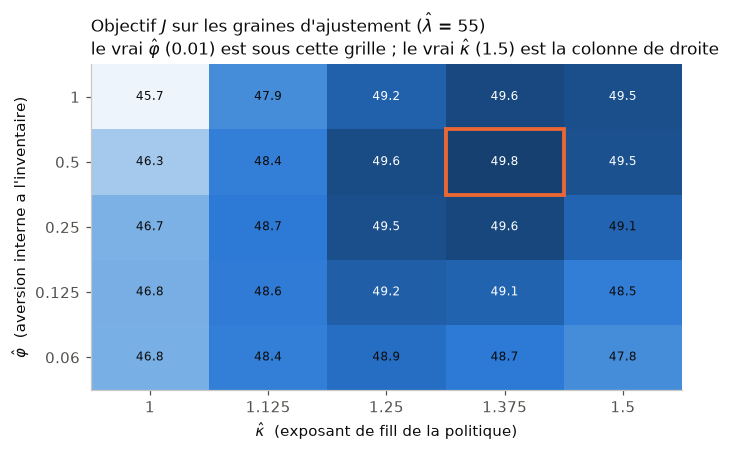

In [7]:
# L'objectif sur le plan (kappa, phi) a l'intensite du vainqueur : une magnitude ordonnee, donc une rampe
# sequentielle a une seule teinte.
table = pd.DataFrame(refined_rows)
plane = table[table.intensity == rich_winner["intensity"]].pivot(
    index="per_step_inventory_aversion", columns="fill_exponent", values="objective")

fig, ax = plt.subplots(figsize=(6.4, 4.2))
ax.grid(False)
image = ax.imshow(plane.values, cmap=SEQUENTIAL, origin="lower", aspect="auto")
ax.set_xticks(range(len(plane.columns)), [f"{c:g}" for c in plane.columns])
ax.set_yticks(range(len(plane.index)), [f"{i:g}" for i in plane.index])
ax.set_xlabel("$\\hat\\kappa$  (exposant de fill de la politique)")
ax.set_ylabel("$\\hat\\varphi$  (aversion interne a l'inventaire)")
for i in range(plane.shape[0]):
    for j in range(plane.shape[1]):
        value = plane.values[i, j]
        ax.text(j, i, f"{value:.1f}", ha="center", va="center", fontsize=8,
                color="#ffffff" if value > np.nanquantile(plane.values, 0.6) else INK)
best_j = list(plane.columns).index(rich_winner["fill_exponent"])
best_i = list(plane.index).index(rich_winner["per_step_inventory_aversion"])
ax.add_patch(plt.Rectangle((best_j - .5, best_i - .5), 1, 1, fill=False, edgecolor=NAIVE, linewidth=2.5))
ax.set_title(f"Objectif $J$ sur les graines d'ajustement ($\\hat\\lambda$ = {rich_winner['intensity']:g})\n"
             f"le vrai $\\hat\\varphi$ (0.01) est sous cette grille ; le vrai $\\hat\\kappa$ (1.5) est la colonne de droite", loc="left")
plt.tight_layout()

### Ce qui a bougé

Les trois paramètres se déplacent dans la direction que le mécanisme prédit, et l'un domine largement.

| Paramètre | Vrai | Recalibré | Lecture |
|---|---|---|---|
| $\hat\varphi$ | 0.01 | **0.5** — 50× | la forme fermée doit se croire **beaucoup** plus averse à l'inventaire : ne voyant pas $\alpha$, sa seule défense est de refuser de porter du stock |
| $\hat\lambda$ | 140 | **55** — 2.5× moins | elle doit se croire moins de chances de déboucler, ce qui la rend plus prudente à inventaire égal |
| $\hat\kappa$ | 1.5 | 1.375 | elle élargit légèrement son spread : le flux qu'elle capte est plus toxique qu'elle ne le croit |

Les trois vont dans la direction que le mécanisme prédit, et $\hat\varphi$ domine. $\hat\alpha$, lui, est **inerte** :
le sweep ci-dessous le déplace d'un facteur 30 pour un effet plus petit qu'une erreur type. C'est cohérent — avec un
inventaire terminal moyen sous 0.5, la pénalité terminale ne mord presque jamais. La grille de raffinement le fixe
donc à la valeur trouvée par la passe grossière ; le sweep montre que ce choix ne change rien.

In [8]:
sweep = [evaluate_parameters(fit_env(SENSITIVITY), FIT_SEEDS, **{**rich_winner, "terminal_inventory_aversion": a})
         for a in (1.0, 3.0, 10.0, 30.0)]
pd.DataFrame(sweep)[["terminal_inventory_aversion", "objective", "objective_se"]].round(3)

,terminal_inventory_aversion,objective,objective_se
0,1.0,50.032,0.158
1,3.0,49.790,0.189
2,10.0,49.760,0.194
3,30.0,49.760,0.194


## 4. Évaluation held-out — le tableau à trois bras

Toutes les lignes sont évaluées sur les **mêmes cinq graines**, disjointes de celles de la recherche, avec
2000 trajectoires chacune. Comparaison appariée.

In [9]:
arms = {
    "E_closed  CF-naif (= optimum derive)": (0.0, TRUE_PARAMETERS),
    "E_rich    CF-naif": (SENSITIVITY, TRUE_PARAMETERS),
    "E_rich    CF-recalibre": (SENSITIVITY, rich_winner),
}
summary = pd.DataFrame(
    [{"bras": name, **{k: v for k, v in held_out(sensitivity, parameters).items()
                       if k in ("objective", "objective_se", "mean_pnl", "pnl_std",
                                "mean_abs_terminal_inventory")}}
     for name, (sensitivity, parameters) in arms.items()]).set_index("bras")
summary.round(3)

,objective,objective_se,mean_pnl,pnl_std,mean_abs_terminal_inventory
bras,,,,,
E_closed CF-naif (= optimum derive),67.006,0.129,67.625,10.289,0.408
E_rich CF-naif,36.781,0.139,48.457,21.582,2.025
E_rich CF-recalibre,49.358,0.020,50.363,9.938,0.439


In [10]:
optimum = summary.loc["E_closed  CF-naif (= optimum derive)", "objective"]
naive = summary.loc["E_rich    CF-naif", "objective"]
recalibrated = summary.loc["E_rich    CF-recalibre", "objective"]
total_loss, recovered, residual = optimum - naive, recalibrated - naive, optimum - recalibrated

print(f"perte totale due a l'adverse selection      {total_loss:6.2f}")
print(f"  recuperee par la recalibration            {recovered:6.2f}   ({100 * recovered / total_loss:.0f} %)")
print(f"  residuelle apres recalibration            {residual:6.2f}   ({100 * residual / total_loss:.0f} %)")
print()
print(f"Un agent RL qui observe alpha ne peut revendiquer au mieux que ces {residual:.2f}, pas les "
      f"{total_loss:.2f} du Test 3.")

perte totale due a l'adverse selection       30.23
  recuperee par la recalibration             12.58   (42 %)
  residuelle apres recalibration             17.65   (58 %)

Un agent RL qui observe alpha ne peut revendiquer au mieux que ces 17.65, pas les 30.23 du Test 3.


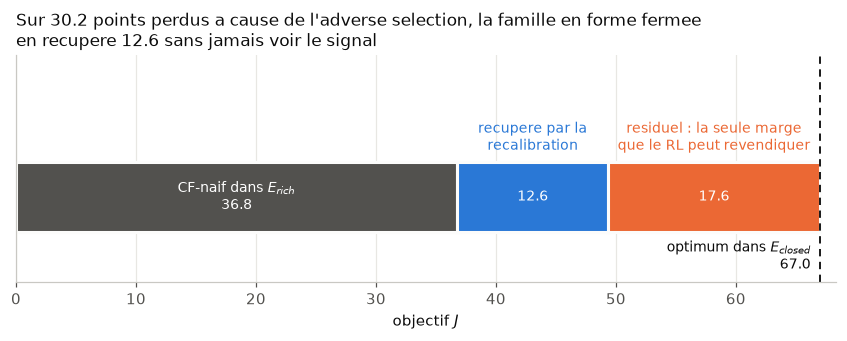

In [11]:
fig, ax = plt.subplots(figsize=(7.8, 3.2))
ax.grid(False)
ax.xaxis.grid(True)

segments = [(naive, CLOSED, f"CF-naif dans $E_{{rich}}$\n{naive:.1f}", None),
            (recovered, RECALIBRATED, f"{recovered:.1f}", "recupere par la\nrecalibration"),
            (residual, NAIVE, f"{residual:.1f}", "residuel : la seule marge\nque le RL peut revendiquer")]
left = 0.0
for width, colour, inside, above in segments:
    ax.barh(0, width, left=left, color=colour, height=0.5, edgecolor="#fcfcfb", linewidth=2)
    ax.text(left + width / 2, 0, inside, ha="center", va="center", color="#ffffff", fontsize=9)
    if above:
        ax.annotate(above, (left + width / 2, 0.30), ha="center", va="bottom", fontsize=9, color=colour)
    left += width

ax.axvline(optimum, color=INK, linewidth=1.2, linestyle=(0, (4, 3)))
ax.annotate(f"optimum dans $E_{{closed}}$\n{optimum:.1f}", (optimum, -0.42), ha="right", va="center",
            fontsize=9, color=INK, xytext=(-6, 0), textcoords="offset points")
ax.set_yticks([])
ax.set_ylim(-0.6, 1.0)
ax.set_xlim(0, optimum * 1.02)
ax.set_xlabel("objectif $J$")
ax.set_title(f"Sur {total_loss:.1f} points perdus a cause de l'adverse selection, la famille en forme fermee\n"
             f"en recupere {recovered:.1f} sans jamais voir le signal", loc="left")
plt.tight_layout()

## 5. Comment les deux politiques diffèrent

Le PnL moyen est une statistique plate autour de l'optimum : deux politiques très différentes peuvent donner des
PnL proches. La surface de politique $\delta^*(q)$ dit ce que le PnL cache.

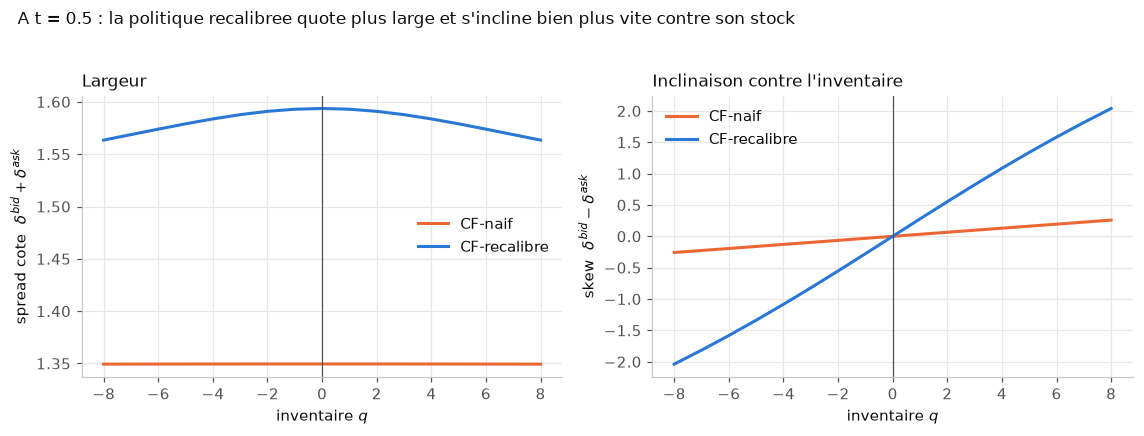

In [12]:
inventories = np.arange(-8, 9)
probe_env = get_env(SENSITIVITY, len(inventories), seed=0)
state = np.zeros((len(inventories), 5))
state[:, TIME_INDEX], state[:, INVENTORY_INDEX] = 0.5, inventories

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
for colour, parameters, label in ((NAIVE, TRUE_PARAMETERS, "CF-naif"),
                                  (RECALIBRATED, rich_winner, "CF-recalibre")):
    action = RecalibratedCarteaJaimungalMmAgent(env=probe_env, **parameters).get_action(state)
    axes[0].plot(inventories, action[:, BID_INDEX] + action[:, ASK_INDEX], color=colour, label=label)
    axes[1].plot(inventories, action[:, BID_INDEX] - action[:, ASK_INDEX], color=colour, label=label)

axes[0].set_ylabel("spread cote  $\\delta^{bid} + \\delta^{ask}$")
axes[0].set_title("Largeur", loc="left")
axes[1].set_ylabel("skew  $\\delta^{bid} - \\delta^{ask}$")
axes[1].set_title("Inclinaison contre l'inventaire", loc="left")
for ax in axes:
    ax.set_xlabel("inventaire $q$")
    ax.axvline(0, color=MUTED, linewidth=0.8)
    ax.legend()
fig.suptitle("A t = 0.5 : la politique recalibree quote plus large et s'incline bien plus vite contre son stock",
             y=1.03, x=0.02, ha="left", fontsize=11)
plt.tight_layout()

## 6. Attaque : la recalibration est-elle spécifique à l'environnement ?

Si le vainqueur de $E_\text{rich}$ gagnait aussi dans $E_\text{closed}$, on n'aurait pas trouvé une adaptation à
l'adverse selection — on aurait trouvé un meilleur a priori, et le Test 3 aurait simplement comparé la forme fermée
à une version mal réglée d'elle-même.

In [13]:
attack = pd.DataFrame([
    {"parametres": "vrais", **held_out(0.0, TRUE_PARAMETERS)},
    {"parametres": "vainqueur de E_rich", **held_out(0.0, rich_winner)},
]).set_index("parametres")[["objective", "objective_se", "mean_pnl", "mean_abs_terminal_inventory"]]
print("Evalues dans E_closed, sur les graines held-out :\n")
print(attack.round(3))

penalty = attack.loc["vrais", "objective"] - attack.loc["vainqueur de E_rich", "objective"]
assert penalty > 0, "le vainqueur de E_rich gagne aussi dans E_closed -- ce n'est pas une adaptation"
print(f"\n-> le vainqueur de E_rich PERD {penalty:.2f} points dans E_closed. La recalibration est bien une "
      f"adaptation\n   a l'adverse selection, pas un meilleur reglage universel.")

Evalues dans E_closed, sur les graines held-out :

                     objective  objective_se  mean_pnl  \
parametres                                               
vrais                   67.006         0.129    67.625   
vainqueur de E_rich     63.882         0.085    63.981   

                     mean_abs_terminal_inventory  
parametres                                        
vrais                                      0.408  
vainqueur de E_rich                        0.078  

-> le vainqueur de E_rich PERD 3.12 points dans E_closed. La recalibration est bien une adaptation
   a l'adverse selection, pas un meilleur reglage universel.


## Ce que cette couche change pour la suite

| | Avant (Test 3) | Après |
|---|---|---|
| Ce à quoi le RL est comparé | forme fermée mal spécifiée | meilleure politique de la famille fermée |
| Marge revendicable | la perte totale | seulement le résidu |

**La barre a monté, et c'est le but.** Un agent RL qui bat le CF-naïf ne prouve rien : il bat une politique qui
porte les paramètres d'un autre monde. Il doit battre le CF-recalibré, qui a déjà récupéré une large part de la
perte **sans jamais voir $\alpha$**, uniquement en refusant de porter du stock.

**Ce qui reste ouvert.** Le résidu se décompose encore en deux parts qu'on n'a pas séparées :

1. la partie **irréductible** — le coût de l'adverse selection qu'aucune politique ne peut éviter ;
2. la partie **capturable** — ce qu'une politique qui observe $\alpha$ peut récupérer.

C'est cette seconde part, et elle seule, qui est la contribution possible d'un agent RL. Une borne supérieure
s'obtiendrait en résolvant numériquement le HJB avec $\alpha$ dans l'état, ou plus simplement en donnant à un agent
un accès oracle au signal : la couche suivante.

**Une réserve à garder en tête.** La famille CJ n'a que quatre paramètres et aucun d'eux ne dépend de $\alpha$ ;
elle ne *peut* pas exprimer une politique qui réagit au signal. Le CF-recalibré est donc le meilleur benchmark
disponible, pas une borne supérieure sur ce que la théorie sait faire. Une forme fermée dérivée *avec* le signal
(la littérature « market making with alpha signals » en donne une pour le couplage dérive seule) serait un bras
supplémentaire, plus exigeant encore.